<a href="https://colab.research.google.com/github/Aryamaan777/Finance/blob/ReinforcementLearningAndDecisionMaking/ReinforcementLearningAndDecisionMaking/Policy_Gradient_Methods.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

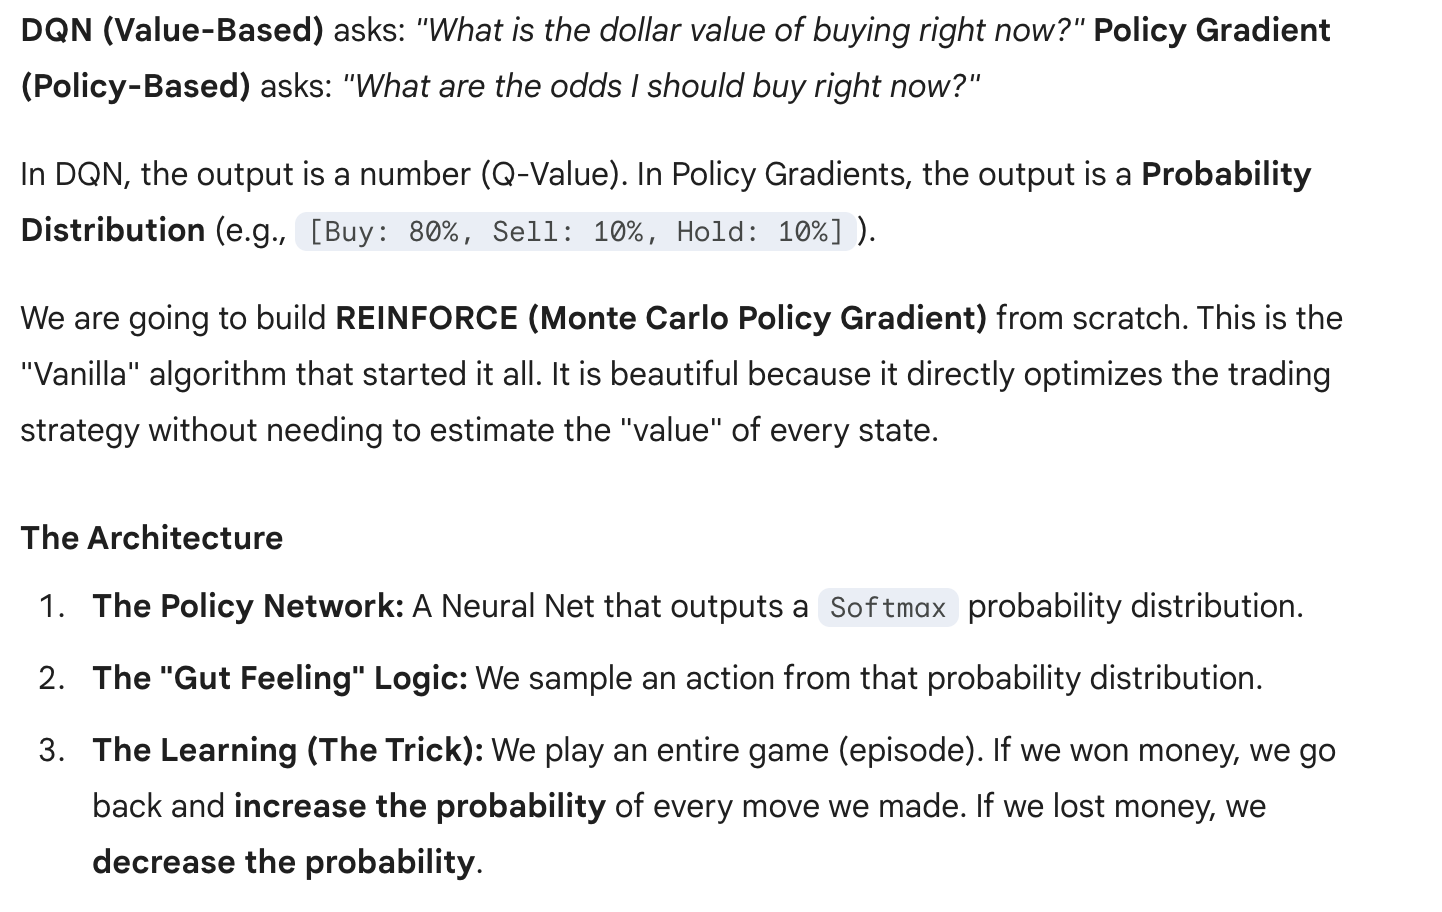

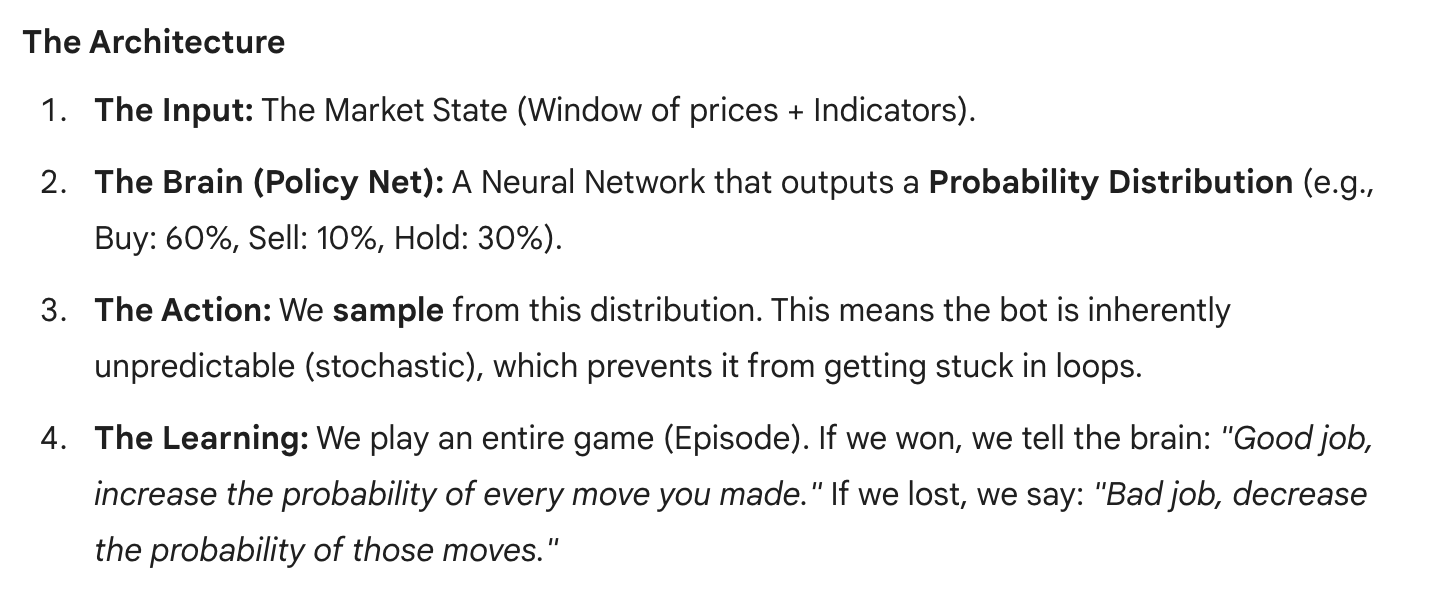

In [1]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Categorical

In [2]:
# --- CONFIGURATION ---
TICKER = "NVDA"
START_DATE = "2015-01-01"
END_DATE = "2024-01-01"
WINDOW_SIZE = 30        # AI sees the last 30 days
INITIAL_BALANCE = 10000
TRANSACTION_FEE = 0.001 # 0.1% fee per trade
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
# --- DATA LOADING ---
def get_data(ticker):
    print(f"⬇️ Downloading data for {ticker}...")
    df = yf.download(ticker, start=START_DATE, end=END_DATE, progress=False)

    # Fix: Flatten MultiIndex columns if present (common yfinance issue)
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)

    # Calculate Indicators
    # 1. RSI (Relative Strength Index)
    delta = df['Close'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
    rs = gain / loss
    df['RSI'] = 100 - (100 / (1 + rs))

    # 2. MACD
    ema12 = df['Close'].ewm(span=12, adjust=False).mean()
    ema26 = df['Close'].ewm(span=26, adjust=False).mean()
    df['MACD'] = ema12 - ema26

    # 3. Volatility (Rolling Standard Deviation)
    df['Vol'] = df['Close'].pct_change().rolling(20).std()

    # Clean up
    df.dropna(inplace=True)
    df.reset_index(drop=True, inplace=True)

    # Features: Open, High, Low, Close, Volume, RSI, MACD, Vol
    return df[['Open', 'High', 'Low', 'Close', 'Volume', 'RSI', 'MACD', 'Vol']]

In [4]:
# Prepare Datasets
full_df = get_data(TICKER)
split_idx = int(len(full_df) * 0.8)
train_df = full_df.iloc[:split_idx].reset_index(drop=True)
test_df = full_df.iloc[split_idx:].reset_index(drop=True)

print(f"✅ Data Ready: {len(train_df)} Train Days | {len(test_df)} Test Days")

⬇️ Downloading data for NVDA...


/tmp/ipython-input-4083946322.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=START_DATE, end=END_DATE, progress=False)


✅ Data Ready: 1795 Train Days | 449 Test Days


In [5]:
class TradingEnv(gym.Env):
    def __init__(self, df):
        super(TradingEnv, self).__init__()
        self.df = df
        self.max_steps = len(self.df) - 1

        # Actions: 0=Hold, 1=Buy, 2=Sell
        self.action_space = spaces.Discrete(3)

        # Observation: 30 days x 8 features
        self.observation_space = spaces.Box(
            low=-np.inf, high=np.inf, shape=(WINDOW_SIZE, 8), dtype=np.float32
        )

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.current_step = WINDOW_SIZE
        self.balance = INITIAL_BALANCE
        self.shares_held = 0
        self.net_worth = INITIAL_BALANCE
        self.max_net_worth = INITIAL_BALANCE
        return self._get_observation(), {}

    def _get_observation(self):
        # Get the 30-day window
        frame = self.df.iloc[self.current_step - WINDOW_SIZE : self.current_step].values
        obs = frame.copy()

        # NORMALIZE (Crucial for Neural Nets)
        # 1. Prices (Cols 0-3): Divide by the first Close price of the window
        base_price = float(obs[0, 3])
        obs[:, :4] = obs[:, :4] / base_price

        # 2. Volume (Col 4): Divide by mean volume
        vol_base = np.mean(obs[:, 4]) + 1e-9
        obs[:, 4] = obs[:, 4] / vol_base

        # 3. RSI (Col 5): Scale 0-100 to 0-1
        obs[:, 5] = obs[:, 5] / 100.0

        # 4. MACD (Col 6): Divide by base price
        obs[:, 6] = obs[:, 6] / base_price

        # 5. Vol (Col 7): Already small, leave as is

        return obs.astype(np.float32)

    def step(self, action):
        # 1. CAPTURE PREVIOUS STATE (Before moving time forward)
        # We need these to calculate returns later
        prev_net_worth = self.net_worth
        prev_price = float(self.df.loc[self.current_step, 'Close'])

        # 2. EXECUTE ACTION (At current price)
        # We trade at the price of "today" before moving to "tomorrow"

        reward = 0
        if action == 1: # BUY
            if self.balance > 0:
                cost = self.balance * (1 - TRANSACTION_FEE)
                self.shares_held += cost / prev_price
                self.balance = 0
                reward+=1

        elif action == 2: # SELL
            if self.shares_held > 0:
                revenue = self.shares_held * prev_price * (1 - TRANSACTION_FEE)
                self.balance += revenue
                self.shares_held = 0

        # 3. MOVE TIME FORWARD
        self.current_step += 1

        # 4. GET NEW STATE (Tomorrow's Price)
        # We need to know what our portfolio is worth *now* (at t+1)
        current_price = float(self.df.loc[self.current_step, 'Close'])

        # Calculate Current Net Worth using the NEW price
        current_net_worth = self.balance + (self.shares_held * current_price)

        # 5. CALCULATE REWARD (Alpha-Based)
        # How much did we grow?
        portfolio_return = (current_net_worth - prev_net_worth) / prev_net_worth if prev_net_worth > 0 else 0

        # How much did the market grow?
        market_return = (current_price - prev_price) / prev_price if prev_price > 0 else 0

        # Reward = Outperformance (Alpha)
        # If we beat the market, positive reward. If we trail, negative.
        reward += (portfolio_return - market_return) * 100

        # 6. UPDATE MEMORY & CHECK TERMINATION
        self.net_worth = current_net_worth
        self.max_net_worth = max(self.max_net_worth, self.net_worth)

        # Stop if we lose 50% of money
        terminated = self.net_worth < INITIAL_BALANCE * 0.5
        # Stop if we run out of data
        truncated = self.current_step >= len(self.df) - 1

        return self._get_observation(), reward, terminated, truncated, {'net_worth': self.net_worth}

print("✅ Environment Class Defined.")

✅ Environment Class Defined.


In [6]:
class PolicyNetwork(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(PolicyNetwork, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(p=0.2), # Randomly disables neurons to prevent overfitting
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, output_dim),
            nn.Softmax(dim=-1) # Output: Probabilities [Buy%, Sell%, Hold%]
        )

    def forward(self, x):
        return self.net(x)

print("✅ Policy Network Defined.")

✅ Policy Network Defined.


In [7]:
class ReinforceAgent:
    def __init__(self, input_dim, action_dim, lr=0.001):
        self.policy = PolicyNetwork(input_dim, action_dim).to(DEVICE)
        self.optimizer = optim.Adam(self.policy.parameters(), lr=lr)
        self.log_probs = [] # Memory of our decisions
        self.rewards = []   # Memory of our results

    def select_action(self, state):
        # Convert state to tensor
        state = torch.FloatTensor(state).flatten().unsqueeze(0).to(DEVICE)

        # Get probabilities from network
        probs = self.policy(state)

        # Create a distribution and sample an action
        m = Categorical(probs)
        action = m.sample()

        # Save log_prob for backpropagation later
        self.log_probs.append(m.log_prob(action))

        return action.item()

    def store_reward(self, reward):
        self.rewards.append(reward)

    def train(self):
        R = 0
        returns = []
        policy_loss = []

        # 1. Calculate Discounted Returns (Working backwards)
        # We value immediate rewards slightly more than distant ones
        gamma = 0.99
        for r in self.rewards[::-1]:
            R = r + gamma * R
            returns.insert(0, R)

        returns = torch.tensor(returns).to(DEVICE)

        # 2. Normalize Returns (Stabilizes training)
        if len(returns) > 1:
            returns = (returns - returns.mean()) / (returns.std() + 1e-9)

        # 3. Calculate Loss
        # We want to increase prob of actions that led to high returns
        # Loss = -Sum(log_prob * return)
        for log_prob, R in zip(self.log_probs, returns):
            policy_loss.append(-log_prob * R)

        # 4. Backpropagate
        self.optimizer.zero_grad()
        if len(policy_loss) > 0:
            loss = torch.stack(policy_loss).sum()
            loss.backward()
            self.optimizer.step()

        # Reset memory
        self.log_probs = []
        self.rewards = []

print("✅ Agent Class Defined.")

✅ Agent Class Defined.


In [8]:
# Initialize
env = TradingEnv(train_df)
input_dim = WINDOW_SIZE * 8 # 30 days * 8 features
action_dim = 3

agent = ReinforceAgent(input_dim, action_dim, lr=0.0005)
num_episodes = 300

print(f"🔥 Starting Training on {DEVICE}...")

for episode in range(num_episodes):
    state, _ = env.reset()
    done = False

    while not done:
        action = agent.select_action(state)
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        agent.store_reward(reward)
        state = next_state

    # Update Policy at the end of every episode
    agent.train()

    if (episode + 1) % 50 == 0:
        print(f"Episode {episode+1}/{num_episodes} | Final Equity: ${env.net_worth:.2f}")

print("✅ Training Complete.")

🔥 Starting Training on cuda...
Episode 50/300 | Final Equity: $177617.32
Episode 100/300 | Final Equity: $29156.39
Episode 150/300 | Final Equity: $129149.16
Episode 200/300 | Final Equity: $122325.00
Episode 250/300 | Final Equity: $103440.51
Episode 300/300 | Final Equity: $132255.87
✅ Training Complete.


🧪 Running Backtest...


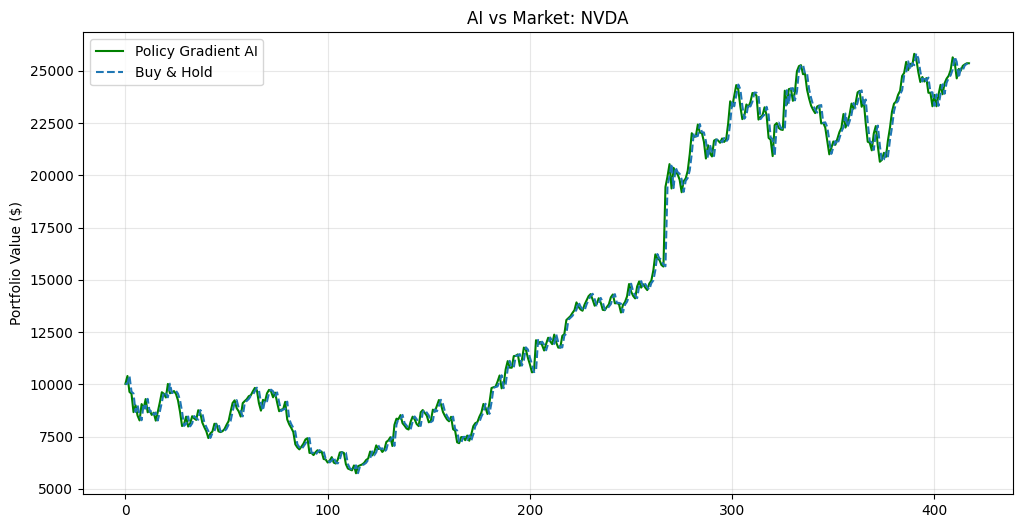

AI Final: $25,358.25


In [9]:
# Setup Test Env
test_env = TradingEnv(test_df)
state, _ = test_env.reset()
done = False
equity_curve = []

print("🧪 Running Backtest...")

while not done:
    with torch.no_grad():
        state_tensor = torch.FloatTensor(state).flatten().unsqueeze(0).to(DEVICE)
        probs = agent.policy(state_tensor)
        # For testing, we pick the BEST action, not random
        action = torch.argmax(probs).item()

    state, _, terminated, truncated, info = test_env.step(action)
    done = terminated or truncated
    equity_curve.append(info['net_worth'])

# Benchmark (Buy & Hold)
initial_price = test_df.iloc[WINDOW_SIZE]['Close']
bench_curve = [10000 * (p / initial_price) for p in test_df['Close'][WINDOW_SIZE:]]

# Plot
plt.figure(figsize=(12, 6))
plt.plot(equity_curve, label='Policy Gradient AI', color='green')
plt.plot(bench_curve, label='Buy & Hold', linestyle='--')
plt.title(f"AI vs Market: {TICKER}")
plt.ylabel("Portfolio Value ($)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"AI Final: ${equity_curve[-1]:,.2f}")

🧪 Running Professional Audit...

📊 STRATEGY PERFORMANCE REPORT
Total Return       152.9%
CAGR               75.0%
Volatility         54.5%
Sharpe Ratio       1.30
Sortino Ratio      2.25
Max Drawdown       -44.8%
Calmar Ratio       1.68
Alpha              70.3%
Beta               0.01
Win Rate (Est)     0.0%


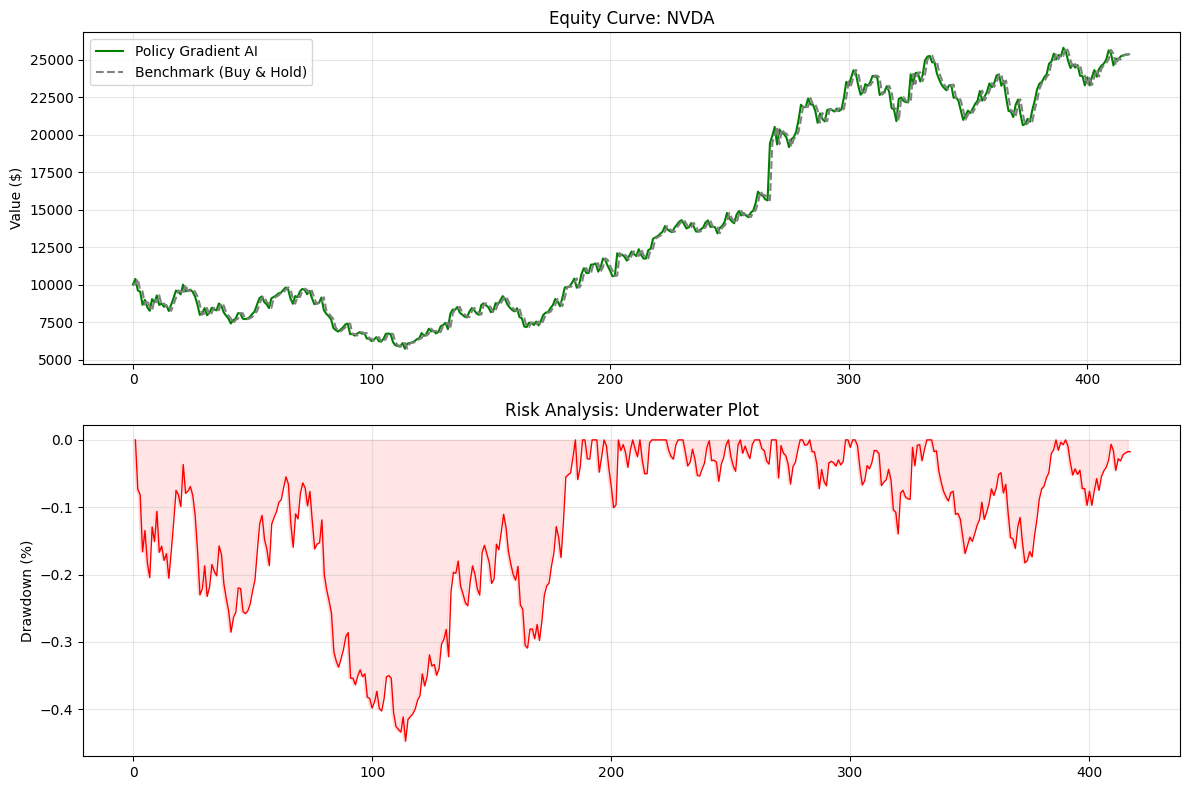

In [10]:
import numpy as np
import pandas as pd
import scipy.stats as stats

# --- 1. RUN BACKTEST & LOG TRADES ---
test_env = TradingEnv(test_df)
state, _ = test_env.reset()
done = False

equity_curve = []
trade_log = [] # We will log trades here manually
action_history = []

print("🧪 Running Professional Audit...")

while not done:
    # Get Action
    with torch.no_grad():
        state_tensor = torch.FloatTensor(state).flatten().unsqueeze(0).to(DEVICE)
        probs = agent.policy(state_tensor)
        action = torch.argmax(probs).item()

    # Capture price before step for logging
    current_price = test_env.df.iloc[test_env.current_step]['Close']

    # Step
    state, _, terminated, truncated, info = test_env.step(action)
    done = terminated or truncated

    # Log Data
    equity_curve.append(info['net_worth'])
    action_history.append(action)

    # Log Trades (Simplified: 1=Buy, 2=Sell)
    # We record the price and action to reconstruct performance later
    if action == 1 or action == 2:
        trade_log.append({
            'Step': test_env.current_step,
            'Type': 'BUY' if action == 1 else 'SELL',
            'Price': current_price,
            'Value': info['net_worth']
        })

# --- 2. METRICS CALCULATOR ---
def calculate_metrics(equity_list, benchmark_list, trades):
    # Convert to Series
    strat = pd.Series(equity_list)
    bench = pd.Series(benchmark_list)

    # Returns
    returns = strat.pct_change().dropna()
    bench_ret = bench.pct_change().dropna()

    # 1. CAGR & Total Return
    total_ret = (strat.iloc[-1] / strat.iloc[0]) - 1
    days = len(strat)
    cagr = (strat.iloc[-1] / strat.iloc[0]) ** (252/days) - 1

    # 2. Risk (Volatility & Sharpe)
    vol = returns.std() * np.sqrt(252)
    sharpe = (returns.mean() / returns.std()) * np.sqrt(252) if vol > 0 else 0

    # 3. Sortino (Downside Risk only)
    downside = returns[returns < 0]
    sortino = (returns.mean() / downside.std()) * np.sqrt(252) if len(downside) > 0 else 0

    # 4. Max Drawdown
    cum_ret = (1 + returns).cumprod()
    peak = cum_ret.cummax()
    drawdown = (cum_ret - peak) / peak
    max_dd = drawdown.min()
    calmar = cagr / abs(max_dd) if max_dd != 0 else 0

    # 5. Alpha & Beta
    # Align lengths just in case
    min_len = min(len(returns), len(bench_ret))
    slope, intercept, _, _, _ = stats.linregress(bench_ret[:min_len], returns[:min_len])
    beta = slope
    alpha = intercept * 252

    # 6. Trade Metrics (Approximate)
    win_rate = 0.0
    if len(trades) > 1:
        # Simple logic: If we sold, was it higher than the last buy?
        # Note: This is a rough estimation for RL agents that switch stance often
        wins = 0
        total_closed = 0
        last_buy = 0

        for t in trades:
            if t['Type'] == 'BUY':
                last_buy = t['Price']
            elif t['Type'] == 'SELL' and last_buy > 0:
                if t['Price'] > last_buy:
                    wins += 1
                total_closed += 1
                last_buy = 0 # Reset

        win_rate = wins / total_closed if total_closed > 0 else 0

    return {
        "Total Return": f"{total_ret*100:.1f}%",
        "CAGR": f"{cagr*100:.1f}%",
        "Volatility": f"{vol*100:.1f}%",
        "Sharpe Ratio": f"{sharpe:.2f}",
        "Sortino Ratio": f"{sortino:.2f}",
        "Max Drawdown": f"{max_dd*100:.1f}%",
        "Calmar Ratio": f"{calmar:.2f}",
        "Alpha": f"{alpha*100:.1f}%",
        "Beta": f"{beta:.2f}",
        "Win Rate (Est)": f"{win_rate*100:.1f}%"
    }, drawdown

# --- 3. EXECUTE REPORT ---
# Create Benchmark Curve (Buy & Hold)
initial_close = test_df.iloc[WINDOW_SIZE]['Close']
bench_curve = [10000 * (p / initial_close) for p in test_df['Close'][WINDOW_SIZE:]]

metrics, dd_curve = calculate_metrics(equity_curve, bench_curve, trade_log)

print("\n" + "="*30)
print("📊 STRATEGY PERFORMANCE REPORT")
print("="*30)
for k, v in metrics.items():
    print(f"{k:<18} {v}")
print("="*30)

# --- 4. VISUALIZATION ---
plt.figure(figsize=(12, 8))

# Equity Curve
plt.subplot(2, 1, 1)
plt.plot(equity_curve, label='Policy Gradient AI', color='green')
plt.plot(bench_curve, label='Benchmark (Buy & Hold)', color='gray', linestyle='--')
plt.title(f"Equity Curve: {TICKER}")
plt.ylabel("Value ($)")
plt.legend()
plt.grid(True, alpha=0.3)

# Underwater Plot
plt.subplot(2, 1, 2)
plt.plot(dd_curve, label='Drawdown', color='red', linewidth=1)
plt.fill_between(range(len(dd_curve)), dd_curve, 0, color='red', alpha=0.1)
plt.title("Risk Analysis: Underwater Plot")
plt.ylabel("Drawdown (%)")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()